# 1. Install packages


In [ ]:
!pip install -q transformers accelerate scikit-learn

# 2. Imports


In [ ]:
import numpy as np
import pandas as pd
import torch

from torch.utils.data import Dataset
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    DataCollatorWithPadding
)


#  3. Reproducibility

In [ ]:
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# 4.  split dataframes

In [ ]:
train_df = pd.read_csv("train_balanced.csv")
val_df   = pd.read_csv("validation.csv")
test_df  = pd.read_csv("test.csv")

In [ ]:
TEXT_COL = "review_text"
LABEL_COL = "Score"

# 5. Keep only needed columns

In [ ]:
train_df = train_df[[TEXT_COL, LABEL_COL]].copy()
val_df   = val_df[[TEXT_COL, LABEL_COL]].copy()
test_df  = test_df[[TEXT_COL, LABEL_COL]].copy()

# Clean missing values
for df in [train_df, val_df, test_df]:
    df[TEXT_COL] = df[TEXT_COL].astype(str).str.strip()
    df.dropna(subset=[TEXT_COL, LABEL_COL], inplace=True)
    df = df[df[TEXT_COL] != ""]

# Make sure labels are integers
train_df[LABEL_COL] = train_df[LABEL_COL].astype(int)
val_df[LABEL_COL]   = val_df[LABEL_COL].astype(int)
test_df[LABEL_COL]  = test_df[LABEL_COL].astype(int)

print("Train shape:", train_df.shape)
print("Val shape  :", val_df.shape)
print("Test shape :", test_df.shape)

print("\nTrain label distribution:")
print(train_df[LABEL_COL].value_counts().sort_index())

print("\nVal label distribution:")
print(val_df[LABEL_COL].value_counts().sort_index())

print("\nTest label distribution:")
print(test_df[LABEL_COL].value_counts().sort_index())


Train shape: (75000, 2)
Val shape  : (44767, 2)
Test shape : (89535, 2)

Train label distribution:
Score
1    15000
2    15000
3    15000
4    15000
5    15000
Name: count, dtype: int64

Val label distribution:
Score
1     4420
2     2461
3     3487
4     6340
5    28059
Name: count, dtype: int64

Test label distribution:
Score
1     8839
2     4923
3     6973
4    12680
5    56120
Name: count, dtype: int64


# Convert labels from 1..5 to 0..4

In [ ]:
label_map = {1: 0, 2: 1, 3: 2, 4: 3, 5: 4}
reverse_label_map = {0: "1", 1: "2", 2: "3", 3: "4", 4: "5"}

train_df["label"] = train_df[LABEL_COL].map(label_map)
val_df["label"]   = val_df[LABEL_COL].map(label_map)
test_df["label"]  = test_df[LABEL_COL].map(label_map)

# Safety check
assert train_df["label"].isna().sum() == 0, "Train labels contain unexpected values"
assert val_df["label"].isna().sum() == 0, "Val labels contain unexpected values"
assert test_df["label"].isna().sum() == 0, "Test labels contain unexpected values"

# 7. Tokenizer

In [ ]:
MODEL_NAME = "bert-base-cased"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

# 8. Custom PyTorch Dataset

In [ ]:
class ReviewDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length=256):
        self.texts = texts.tolist()
        self.labels = labels.tolist()
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = str(self.texts[idx])
        label = int(self.labels[idx])

        encoding = self.tokenizer(
            text,
            truncation=True,
            padding=False,          # dynamic padding will be handled by data collator
            max_length=self.max_length,
            return_tensors="pt"
        )

        item = {key: val.squeeze(0) for key, val in encoding.items()}
        item["labels"] = torch.tensor(label, dtype=torch.long)
        return item

# Create datasets
train_dataset = ReviewDataset(
    train_df[TEXT_COL],
    train_df["label"],
    tokenizer,
    max_length=256
)

val_dataset = ReviewDataset(
    val_df[TEXT_COL],
    val_df["label"],
    tokenizer,
    max_length=256
)

test_dataset = ReviewDataset(
    test_df[TEXT_COL],
    test_df["label"],
    tokenizer,
    max_length=256
)

# 9. Data collator for dynamic padding

In [ ]:
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)


# 10. Load model

In [ ]:
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=5,
    id2label=reverse_label_map,
    label2id={"1": 0, "2": 1, "3": 2, "4": 3, "5": 4}
)

model.safetensors:   0%|          | 0.00/436M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


# 11. Metrics

In [ ]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)

    acc = accuracy_score(labels, preds)
    macro_f1 = f1_score(labels, preds, average="macro")
    weighted_f1 = f1_score(labels, preds, average="weighted")

    return {
        "accuracy": acc,
        "macro_f1": macro_f1,
        "weighted_f1": weighted_f1
    }

# 12. Training arguments

In [ ]:
training_args = TrainingArguments(
    output_dir="./bert_amazon_results",
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_strategy="epoch",
    learning_rate=1e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=3,
    weight_decay=0.01,
    load_best_model_at_end=True,
    metric_for_best_model="accuracy",
    greater_is_better=True,
    report_to="none",
    save_total_limit=1,
    fp16=torch.cuda.is_available()
)

# 13. Trainer

In [ ]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    data_collator=data_collator,
    compute_metrics=compute_metrics
)

# 14. Train

In [ ]:
trainer.train()

In [ ]:
trainer.train()


Epoch,Training Loss,Validation Loss,Accuracy,Macro F1,Weighted F1
1,0.921506,0.705200,0.721536,0.621755,0.741407
2,0.709626,0.596941,0.772511,0.669412,0.782615
3,0.565844,0.698194,0.752496,0.664978,0.768452


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

TrainOutput(global_step=28125, training_loss=0.732325, metrics={'train_runtime': 3761.7093, 'train_samples_per_second': 59.813, 'train_steps_per_second': 7.477, 'total_flos': 2.4249362686695936e+16, 'train_loss': 0.732325, 'epoch': 3.0})

# 15. Validation results

In [ ]:
val_results = trainer.evaluate(val_dataset)
print("\nValidation results:")
print(val_results)


Validation results:
{'eval_loss': 0.5979042649269104, 'eval_accuracy': 0.7722652846963165, 'eval_macro_f1': 0.6693352237431489, 'eval_weighted_f1': 0.7824775906241207, 'eval_runtime': 175.4953, 'eval_samples_per_second': 255.089, 'eval_steps_per_second': 31.887, 'epoch': 3.0}


# 16. Test results

In [ ]:
test_results = trainer.evaluate(test_dataset)
print("\nTest results:")
print(test_results)


Test results:
{'eval_loss': 0.6008838415145874, 'eval_accuracy': 0.772513542190205, 'eval_macro_f1': 0.6696470444278816, 'eval_weighted_f1': 0.7832548281572776, 'eval_runtime': 341.2614, 'eval_samples_per_second': 262.365, 'eval_steps_per_second': 32.796, 'epoch': 3.0}


# 17. Detailed test report

In [ ]:
pred_output = trainer.predict(test_dataset)
y_true = pred_output.label_ids
y_pred = np.argmax(pred_output.predictions, axis=1)

print("\nClassification Report:")
print(classification_report(
    y_true,
    y_pred,
    target_names=["1", "2", "3", "4", "5"]
))

print("\nConfusion Matrix:")
print(confusion_matrix(y_true, y_pred))


Classification Report:
              precision    recall  f1-score   support

           1       0.80      0.76      0.78      8839
           2       0.50      0.62      0.56      4923
           3       0.57      0.62      0.60      6973
           4       0.47      0.62      0.53     12680
           5       0.93      0.84      0.88     56120

    accuracy                           0.77     89535
   macro avg       0.66      0.69      0.67     89535
weighted avg       0.80      0.77      0.78     89535


Confusion Matrix:
[[ 6695  1640   360    56    88]
 [  850  3051   869   103    50]
 [  259  1044  4357  1142   171]
 [  134   148  1334  7801  3263]
 [  386   174   685  7612 47263]]


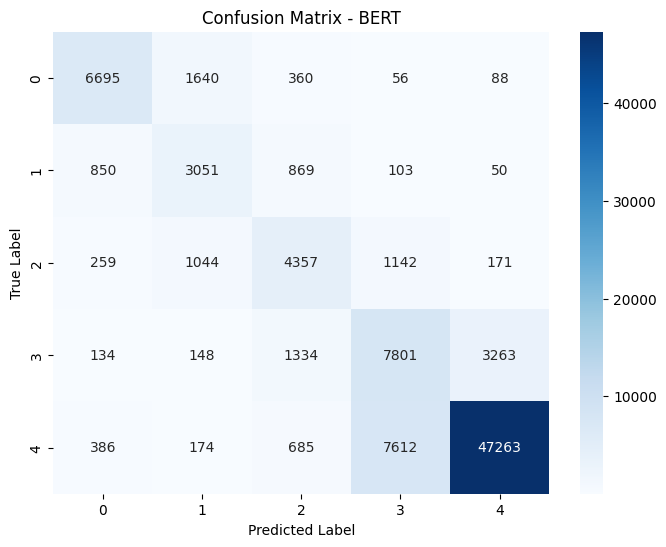

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Confusion Matrix data of BERT
cm = np.array([
    [6695, 1640,  360,   56,   88],
    [ 850, 3051,  869,  103,   50],
    [ 259, 1044, 4357, 1142,  171],
    [ 134,  148, 1334, 7801, 3263],
    [ 386,  174,  685, 7612, 47263]
])



plt.figure(figsize=(8,6))

sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues')

plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix - BERT')

plt.show()

In [ ]:
import json
from google.colab import files

uploaded = files.upload()
filename = list(uploaded.keys())[0]

with open(filename, 'r') as f:
    nb = json.load(f)

# Completely remove widgets metadata (safest for GitHub)
if 'metadata' in nb:
    if 'widgets' in nb['metadata']:
        del nb['metadata']['widgets']

# Save and download
with open(f"Bert{filename}", 'w') as f:
    json.dump(nb, f, indent=2)

files.download(f"Bert{filename}")

Saving Bert_Base_Cased.ipynb to Bert_Base_Cased.ipynb


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>